# Jev vs GPT: classifying 77 banking intents

[TypeSafe](https://docs.typesafe.ai/api) exposes one evaluation endpoint, `POST /v1/systemone`.
You send it some content plus a **typed question**, and it answers in that type - no parsing
free text. `jev-latest` is the model behind it.

This notebook puts that against OpenAI on a genuinely hard classification task: 77
fine-grained banking support intents, many of them easy to confuse (`declined_transfer` vs
`declined_card_payment`, `card_arrival` vs `card_delivery_estimate`).

The dataset is already in this repo, and so are baselines from Claude Haiku 4.5 on the
**same 201-row test split** - which gives us something to anchor against:

| Prior result | Accuracy |
| --- | --- |
| Chain-of-thought | 79.7% |
| GEPA optimised | 76.1% |
| ACE | 71.6% |

### Making it a fair fight

Both models get the **same instruction string** and the **same bare list of label names** -
no hand-written descriptions for either side. Both are **format-constrained**: Jev through
its `choice` type, OpenAI through a JSON-schema `enum`. Neither can return an answer outside
the label set, so whatever gap appears is about judgement, not about following instructions.
Both are zero-shot.

## 1. Setup

In [1]:
# !pip install requests openai pandas matplotlib tqdm

In [2]:
import collections
import json
import math
import os
import time
from concurrent.futures import ThreadPoolExecutor

import matplotlib.pyplot as plt
import pandas as pd
import requests
from openai import OpenAI
from tqdm.auto import tqdm

/Users/marie/Documents/github/miptgirl_medium/jev/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Keys live in `config.json` outside the repo, so nothing secret is ever committed.

In [3]:
with open("../../config.json") as f:
    config = json.load(f)

JEV_API_KEY = config["JEV_API_KEY"]
openai_client = OpenAI(api_key=config["OPENAI_API_KEY"])

## 2. The data

The full 201-row test split, so the numbers line up with the prior baselines. All 77 intents
are offered as options, even though only 74 of them show up among the test rows.

In [4]:
DATASET = "banking77"
DATA = "../prompt_optimisation_gepa_ace/banking_data_split/"

train_df = pd.read_csv(DATA + "train.csv")
val_df = pd.read_csv(DATA + "val.csv")
test_df = pd.read_csv(DATA + "test.csv")

# every intent is an option at prediction time, not just the ones in the test rows
LABELS = sorted(set(train_df["category"]) | set(val_df["category"]) | set(test_df["category"]))

data = test_df.rename(columns={"category": "gold"}).reset_index(drop=True)
data["record_id"] = data.index.astype(str)

print(f"rows           : {len(data)}")
print(f"labels offered : {len(LABELS)}")
data[["record_id", "text", "gold"]].head()

rows           : 201
labels offered : 77


,record_id,text,gold
0,0,Is it possible for me to change my PIN number?,change_pin
1,1,How long does a transfer from a UK account tak...,balance_not_updated_after_bank_transfer
2,2,Why am I getting declines when trying to make ...,declined_transfer
3,3,What is the $1 transaction on my account?,extra_charge_on_statement
4,4,How much does top up fees cost?,top_up_by_card_charge


In [5]:
INSTRUCTIONS = (
    "Classify this banking customer support message into its intent category. "
    "Choose the single category that best matches what the customer is asking about."
)

records = data[["record_id", "text", "gold"]].to_dict(orient="records")
print(f"{len(records)} records ready")

201 records ready


## 3. One Jev call

This is the whole API. `state` is the content, `questions` is a map of typed questions, and a
`choice` question takes its options as the `criteria` map. Descriptions are optional - we pass
`None` so the model sees nothing but the label names, exactly like the OpenAI side.

The answer comes back as the chosen key plus a **confidence**, which is the part you do not get
from a plain chat completion.

In [6]:
JEV_URL = "https://api.typesafe.ai/v1/systemone"


def call_jev(text, labels, instructions, model="jev-latest"):
    """Ask Jev to pick exactly one label."""
    response = requests.post(
        JEV_URL,
        headers={"Authorization": f"Bearer {JEV_API_KEY}"},
        json={
            "state": text,
            "model": model,
            "questions": {
                "label": {
                    "type": "choice",
                    "instructions": instructions,
                    "criteria": {label: None for label in labels},
                }
            },
        },
        timeout=60,
    )
    response.raise_for_status()
    body = response.json()
    answer = body["answers"]["label"]
    return {
        "label": answer["choice"],
        "confidence": answer.get("confidence"),
        "input_tokens": body["usage"]["input_tokens"],
        "output_tokens": body["usage"]["output_tokens"],
    }

In [7]:
example = records[0]
jev_answer = call_jev(example["text"], LABELS, INSTRUCTIONS)

print("text      :", example["text"])
print("gold      :", example["gold"])
print("jev       :", jev_answer)

text      : Is it possible for me to change my PIN number?
gold      : change_pin
jev       : {'label': 'change_pin', 'confidence': 1.0, 'input_tokens': 1039, 'output_tokens': 826}


## 4. The same question to OpenAI

To keep it a fair comparison the answer has to be pinned to the same label set, which is what
the JSON schema `enum` does - the model cannot invent a category or wrap it in a sentence.

Note what is missing: **no confidence**. OpenAI returns the label and nothing else. You can
approximate one from token logprobs, but it is not the calibrated number Jev hands you, and
some models refuse logprobs outright (`gpt-5-mini` returns a 403).

In [8]:
def call_openai(text, labels, instructions, model):
    """Ask an OpenAI model the same question, constrained to the same labels."""
    response = openai_client.chat.completions.create(
        model=model,
        messages=[
            {"role": "system", "content": instructions},
            {"role": "user", "content": text},
        ],
        response_format={
            "type": "json_schema",
            "json_schema": {
                "name": "classification",
                "strict": True,
                "schema": {
                    "type": "object",
                    "properties": {"label": {"type": "string", "enum": labels}},
                    "required": ["label"],
                    "additionalProperties": False,
                },
            },
        },
        timeout=60,
    )
    return {
        "label": json.loads(response.choices[0].message.content)["label"],
        "confidence": None,  # OpenAI does not give us one
        "input_tokens": response.usage.prompt_tokens,
        "output_tokens": response.usage.completion_tokens,
    }

## 5. Caching

A plain dict saved to one JSON file, keyed `"<model>|<record_id>"`. Two rules make it useful:

1. **Only successful answers are cached.** A failed call is never stored, so re-running a cell
   retries exactly the rows that failed and skips everything that already worked.
2. **The key includes the model**, so adding a model does not re-run the ones already done.

In [9]:
CACHE_FILE = f"cache/{DATASET}.json"


def load_cache():
    if os.path.exists(CACHE_FILE):
        with open(CACHE_FILE) as f:
            return json.load(f)
    return {}


def save_cache(cache):
    os.makedirs("cache", exist_ok=True)
    with open(CACHE_FILE, "w") as f:
        json.dump(cache, f, indent=1)


cache = load_cache()
print(f"{len(cache)} answers already cached")

603 answers already cached


The runner is the only slightly fiddly piece, and only because of two real-world facts: calls
sometimes fail transiently (the TypeSafe API returns a `503` when the model is briefly
unavailable), and running 200+ calls one at a time is slow.

In [10]:
def run_model(model_name, call, records, workers=8):
    """Classify every record with one model, skipping whatever is already cached."""

    def classify(record):
        key = f"{model_name}|{record['record_id']}"
        for attempt in range(3):
            try:
                return key, call(record["text"]), None
            except Exception as error:
                message = str(error)
                # a spent account will not recover on a retry
                if "no credits" in message or "insufficient_quota" in message:
                    return key, None, message[:120]
                if attempt == 2:
                    return key, None, message[:120]
                time.sleep(2**attempt)

    todo = [r for r in records if f"{model_name}|{r['record_id']}" not in cache]
    print(f"{model_name}: {len(records) - len(todo)} cached, {len(todo)} to call")

    failures = []
    with ThreadPoolExecutor(max_workers=workers) as pool:
        for key, answer, error in tqdm(pool.map(classify, todo), total=len(todo)):
            if error:
                failures.append(error)
            else:
                cache[key] = answer
    save_cache(cache)

    if failures:
        print(f"  {len(failures)} calls failed, e.g. {failures[0]}")
        print("  re-run this cell to retry just those")

    # stitch the cached answers back onto the records
    return [
        {"record_id": r["record_id"], "gold": r["gold"], **cache[f"{model_name}|{r['record_id']}"]}
        for r in records
        if f"{model_name}|{r['record_id']}" in cache
    ]

## 6. Run every model

One entry per model. Adding another is one line.

In [11]:
MODELS = {
    "jev-latest": lambda text: call_jev(text, LABELS, INSTRUCTIONS),
    "gpt-5.6-luna": lambda text: call_openai(text, LABELS, INSTRUCTIONS, "gpt-5.6-luna"),
    "gpt-5.6-terra": lambda text: call_openai(text, LABELS, INSTRUCTIONS, "gpt-5.6-terra"),
}

results = {}
for model_name, call in MODELS.items():
    results[model_name] = run_model(model_name, call, records)

jev-latest: 201 cached, 0 to call


0it [00:00, ?it/s]

0it [00:00, ?it/s]

gpt-5.6-luna: 201 cached, 0 to call


0it [00:00, ?it/s]

0it [00:00, ?it/s]

gpt-5.6-terra: 201 cached, 0 to call


0it [00:00, ?it/s]

0it [00:00, ?it/s]

## 7. Scoring

Both models answer with a key from `LABELS`, so scoring is a plain string comparison.

The confidence interval matters more than it looks. On a couple of hundred rows the sampling
error is several points wide - usually wider than the gap people try to read between two
models. Quoting accuracy without it is how benchmarks end up overclaiming.

In [12]:
def wilson_interval(correct, total, z=1.96):
    """95% confidence interval for an accuracy figure."""
    if total == 0:
        return 0.0, 0.0
    p = correct / total
    denominator = 1 + z**2 / total
    centre = (p + z**2 / (2 * total)) / denominator
    margin = z * math.sqrt(p * (1 - p) / total + z**2 / (4 * total**2)) / denominator
    return round(max(0, centre - margin), 4), round(min(1, centre + margin), 4)


rows = []
for model_name, answers in results.items():
    if not answers:
        print(f"{model_name}: no answers at all - skipped")
        continue
    correct = sum(a["label"] == a["gold"] for a in answers)
    low, high = wilson_interval(correct, len(answers))
    rows.append(
        {
            "model": model_name,
            "answered": len(answers),
            "correct": correct,
            "accuracy": round(correct / len(answers), 4),
            "ci_low": low,
            "ci_high": high,
            "input_tokens": sum(a["input_tokens"] or 0 for a in answers),
            "output_tokens": sum(a["output_tokens"] or 0 for a in answers),
        }
    )

scores = pd.DataFrame(rows).sort_values("accuracy", ascending=False).reset_index(drop=True)
scores

,model,answered,correct,accuracy,ci_low,ci_high,input_tokens,output_tokens
0,gpt-5.6-luna,201,173,0.8607,0.8060,0.9018,95789,8941
1,gpt-5.6-terra,201,166,0.8259,0.7675,0.8721,95789,5293
2,jev-latest,201,163,0.8109,0.7512,0.8591,209626,166485


> If a model answered far fewer rows than the others, its accuracy is measured on a different
> (and easier or harder) subset - check `answered` before comparing the numbers.

## 8. The comparison

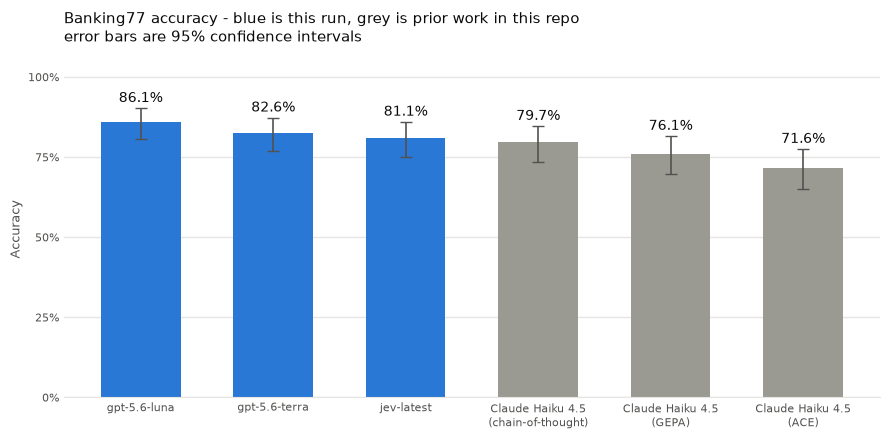

In [13]:
plot_df = scores[["model", "accuracy", "ci_low", "ci_high"]].copy()

# the Claude baselines on this same 201-row split, for context
for name, accuracy in [
    ("Claude Haiku 4.5\n(chain-of-thought)", 0.797),
    ("Claude Haiku 4.5\n(GEPA)", 0.761),
    ("Claude Haiku 4.5\n(ACE)", 0.716),
]:
    low, high = wilson_interval(round(accuracy * 201), 201)
    plot_df.loc[len(plot_df)] = [name, accuracy, low, high]

plot_df["is_baseline"] = plot_df["model"].str.startswith("Claude")
plot_df = plot_df.sort_values("accuracy", ascending=False).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(9, 4.5))

colors = ["#9a9992" if b else "#2a78d6" for b in plot_df["is_baseline"]]
errors = [plot_df["accuracy"] - plot_df["ci_low"], plot_df["ci_high"] - plot_df["accuracy"]]

ax.bar(
    plot_df["model"], plot_df["accuracy"], color=colors, width=0.6,
    yerr=errors, capsize=4, error_kw={"ecolor": "#52514e", "elinewidth": 1.2},
)

# label above the error bar cap so the two do not overlap
for x, (value, high) in enumerate(zip(plot_df["accuracy"], plot_df["ci_high"])):
    ax.text(x, high + 0.02, f"{value:.1%}", ha="center", color="#0b0b0b", fontsize=10)

ax.set_ylim(0, 1.05)
ax.set_yticks([0, 0.25, 0.5, 0.75, 1.0])
ax.set_yticklabels(["0%", "25%", "50%", "75%", "100%"])
ax.set_ylabel("Accuracy", color="#52514e", fontsize=9)
ax.yaxis.grid(True, color="#e6e5e1", linewidth=1)
ax.set_axisbelow(True)
ax.tick_params(colors="#52514e", labelsize=8, length=0)
for side in ("top", "right", "left"):
    ax.spines[side].set_visible(False)
ax.spines["bottom"].set_color("#e6e5e1")
ax.set_title(
    "Banking77 accuracy - blue is this run, grey is prior work in this repo\n"
    "error bars are 95% confidence intervals",
    color="#0b0b0b", fontsize=11, loc="left", pad=14,
)
fig.tight_layout()
plt.show()

## 9. Where the errors are

With 77 intents the headline number matters less than *which* pairs get confused.
A model that mixes up two genuinely adjacent categories is failing differently from one
that picks something unrelated.

In [14]:
for model_name, answers in results.items():
    if not answers:
        continue
    mistakes = [a for a in answers if a["label"] != a["gold"]]
    print(f"\n=== {model_name}: {len(mistakes)} mistakes out of {len(answers)} ===")
    confusions = collections.Counter((a["gold"], a["label"]) for a in mistakes)
    for (gold, predicted), count in confusions.most_common(10):
        print(f"  {count}x  {gold}  ->  {predicted}")


=== jev-latest: 38 mistakes out of 201 ===
  3x  reverted_card_payment?  ->  declined_card_payment
  3x  card_about_to_expire  ->  order_physical_card
  2x  balance_not_updated_after_bank_transfer  ->  transfer_timing
  2x  extra_charge_on_statement  ->  pending_card_payment
  2x  disposable_card_limits  ->  get_disposable_virtual_card
  1x  declined_transfer  ->  declined_card_payment
  1x  balance_not_updated_after_cheque_or_cash_deposit  ->  balance_not_updated_after_bank_transfer
  1x  automatic_top_up  ->  top_up_limits
  1x  cash_withdrawal_not_recognised  ->  receiving_money
  1x  reverted_card_payment?  ->  transaction_charged_twice

=== gpt-5.6-luna: 28 mistakes out of 201 ===
  3x  card_about_to_expire  ->  country_support
  2x  pending_transfer  ->  transfer_timing
  2x  reverted_card_payment?  ->  card_not_working
  1x  declined_transfer  ->  declined_card_payment
  1x  balance_not_updated_after_cheque_or_cash_deposit  ->  balance_not_updated_after_bank_transfer
  1x  auto

## 10. Is the confidence worth anything?

This is the part you cannot do with a plain chat completion. If accuracy climbs with
confidence, you can route the low-confidence tail to a human and leave the rest alone - which
is usually the whole reason to run a classifier at all.

In [15]:
confident = [
    {**a, "model": name}
    for name, answers in results.items()
    for a in answers
    if a.get("confidence") is not None
]

if not confident:
    print("No model returned a confidence.")
else:
    frame = pd.DataFrame(confident)
    frame["correct"] = frame["label"] == frame["gold"]
    frame["bucket"] = pd.cut(
        frame["confidence"], [0, 0.5, 0.7, 0.9, 1.0], include_lowest=True,
        labels=["<=0.5", "0.5-0.7", "0.7-0.9", "0.9-1.0"],
    )
    calibration = (
        frame.groupby(["model", "bucket"], observed=False)["correct"]
        .agg(["mean", "size"])
        .reset_index()
    )
    display(calibration)

,model,bucket,mean,size
0,jev-latest,<=0.5,0.250000,12
1,jev-latest,0.5-0.7,0.560000,25
2,jev-latest,0.7-0.9,0.760870,46
3,jev-latest,0.9-1.0,0.940678,118


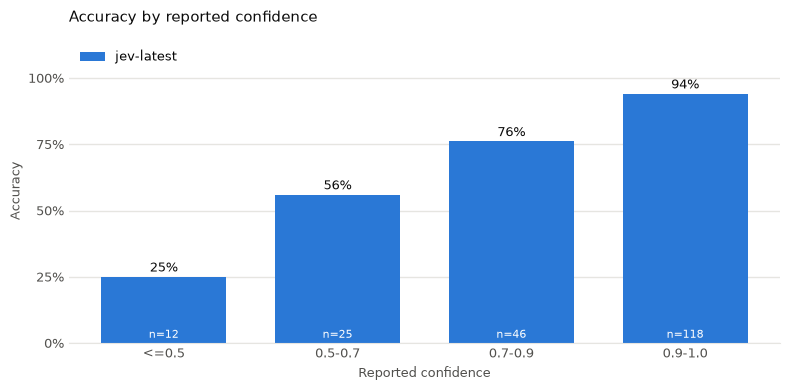

In [16]:
if confident:
    fig, ax = plt.subplots(figsize=(8, 4))
    buckets = ["<=0.5", "0.5-0.7", "0.7-0.9", "0.9-1.0"]
    models = calibration["model"].unique()
    width = 0.8 / len(models)

    for i, model_name in enumerate(models):
        subset = calibration[calibration["model"] == model_name].set_index("bucket")
        subset = subset.reindex(buckets)
        positions = [b + i * width for b in range(len(buckets))]
        ax.bar(
            positions, subset["mean"].fillna(0), width=width * 0.9,
            color=["#2a78d6", "#eb6834", "#1baf7a"][i % 3], label=model_name,
        )
        for position, value, size in zip(positions, subset["mean"], subset["size"].fillna(0)):
            if size:
                ax.text(position, value + 0.02, f"{value:.0%}", ha="center",
                        color="#0b0b0b", fontsize=9)
                ax.text(position, 0.02, f"n={int(size)}", ha="center",
                        color="#ffffff", fontsize=8)

    ax.set_xticks([b + width * (len(models) - 1) / 2 for b in range(len(buckets))])
    ax.set_xticklabels(buckets)
    ax.set_xlabel("Reported confidence", color="#52514e", fontsize=9)
    ax.set_ylabel("Accuracy", color="#52514e", fontsize=9)
    ax.set_ylim(0, 1.15)
    ax.set_yticks([0, 0.25, 0.5, 0.75, 1.0])
    ax.set_yticklabels(["0%", "25%", "50%", "75%", "100%"])
    ax.yaxis.grid(True, color="#e6e5e1", linewidth=1)
    ax.set_axisbelow(True)
    ax.tick_params(colors="#52514e", labelsize=9, length=0)
    for side in ("top", "right", "left"):
        ax.spines[side].set_visible(False)
    ax.spines["bottom"].set_color("#e6e5e1")
    ax.legend(frameon=False, fontsize=9, loc="upper left", ncol=3)
    ax.set_title("Accuracy by reported confidence", color="#0b0b0b",
                 fontsize=11, loc="left", pad=12)
    fig.tight_layout()
    plt.show()

## 11. Save the per-row results

In [17]:
os.makedirs("results", exist_ok=True)

if results:
    flat = pd.DataFrame(
        [{**a, "model": name} for name, answers in results.items() for a in answers]
    )
    flat.to_csv(f"results/{DATASET}_predictions.csv", index=False)
    scores.to_csv(f"results/{DATASET}_summary.csv", index=False)
    print(f"wrote results/{DATASET}_predictions.csv ({len(flat)} rows)")

wrote results/banking77_predictions.csv (603 rows)


## Notes

- **Overlapping intervals mean "not distinguishable".** If two bars sit a couple of points
  apart with overlapping error bars, the honest conclusion is that this test set cannot tell
  them apart. The fix is more rows, not a bolder claim.
- **The Claude baselines came from a different harness** (DSPy, exact-match lowercase), so
  treat them as a sanity anchor rather than a number measured the same way as this run.
- **GEPA and ACE are not zero-shot** - they used the train/val splits to optimise their
  prompts. Chain-of-thought at 79.7% is the like-for-like comparison.
- **Token cost has a different shape per API.** Jev returns a probability over every option, so
  its output tokens scale with the size of the label set. OpenAI under an enum emits just the
  chosen label. Compare cost per correct answer, not raw token counts.
- **Only Jev returns a confidence.** That is the practical difference between the two APIs for
  this kind of task.